# ChatGPT API grading comparison

This notebook evaluates the OpenAI ChatGPT API on every row of `training_data_moh_eng.csv`. It preserves the grading prompt, parser, dataset labels, metrics, checkpointing, and result reports while removing all other model providers.

The API key is read from a local `.env` file and is never displayed. Set `OPENAI_API_KEY`; the model can be overridden with `OPENAI_MODEL`. Synchronous Chat Completions requests are made one example at a time, and completed results are reused when the notebook is restarted.

## 1. Install inference and analysis dependencies



In [17]:
%pip install -U openai httpx zstandard

  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.19.0
    Uninstalling zstandard-0.19.0:
      Successfully uninstalled zstandard-0.19.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and experiment configuration

This section loads the three provider clients and reads their API keys from `.env`. No local model weights or GPU are required.

In [18]:
import ast
import csv
import json
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from openai import OpenAI
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm


def read_env_value(path, key):
    """Read one key from a local dotenv-style file without displaying secrets."""
    if not path.exists():
        raise FileNotFoundError(f"Missing environment file: {path.resolve()}")
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        name, value = line.split("=", 1)
        name = name.strip().removeprefix("export ").strip()
        if name != key:
            continue
        value = value.strip()
        if len(value) >= 2 and value[0] == value[-1] and value[0] in ("'", '"'):
            value = value[1:-1]
        return value
    return None


ENV_PATH = Path("./.env")
OPENAI_API_KEY = read_env_value(ENV_PATH, "OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Missing or empty OPENAI_API_KEY in .env")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-5.6-luna")
OPENAI_CLIENT = OpenAI(api_key=OPENAI_API_KEY)

DATASET_PATH = Path("../Datasets/training_data_moh_eng.csv")
RESULTS_DIR = Path("./base_model_results_gpt")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "openai_gpt56_luna_api_v1"
OVERWRITE_EXISTING = False
THINKING_MODES = [False]
MAX_NEW_TOKENS = {False: 1024, True: 2048}

MODEL_SPECS = [
    {"name": "ChatGPT", "model_id": OPENAI_MODEL, "provider": "openai", "batch_size": 1},
]

print("ChatGPT API client configured.")
print("Model:", OPENAI_MODEL)
print("Modes per model:", len(THINKING_MODES))


ChatGPT API client configured.
Model: gpt-5.6-luna
Modes per model: 1


In [19]:
import httpx


# Force a response encoding that avoids the incompatible zstd decoder path.
OPENAI_HTTP_CLIENT = httpx.Client(
    headers={"Accept-Encoding": "gzip, deflate, identity"},
)
OPENAI_CLIENT = OpenAI(
    api_key=OPENAI_API_KEY,
    default_headers={"Accept-Encoding": "gzip, deflate, identity"},
    http_client=OPENAI_HTTP_CLIENT,
)

print("OpenAI client configured with zstd disabled.")

OpenAI client configured with zstd disabled.


## 3. Load and validate the full dataset

This is the same parser used in the archived notebooks. No train/validation/test split is made: every valid CSV row is included in this base-model benchmark.


In [7]:
def parse_array(value):
    """Parse JSON/Python lists and the dataset's quoted [a,b] format."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if not isinstance(value, str):
        raise TypeError(f"Expected list-like string, got {type(value)}")

    text = value.strip()
    for _ in range(2):
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            break
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, str):
            text = parsed.strip()
            continue
        break

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, str):
            text = parsed.strip()
    except (ValueError, SyntaxError):
        pass

    if not (text.startswith("[") and text.endswith("]")):
        raise ValueError(f"Expected a bracketed list, got: {value!r}")
    inner = text[1:-1].strip()
    if not inner:
        return []
    if re.search(r",(?=Answer\s)", inner):
        items = re.split(r",(?=Answer\s)", inner)
    else:
        items = next(csv.reader([inner], skipinitialspace=True))
    return [item.strip() for item in items]


def parse_criteria(value, expected_count):
    """Use the label count to resolve commas embedded in criteria text."""
    items = parse_array(value)
    if len(items) == expected_count:
        return items

    text = value.strip()
    for _ in range(2):
        try:
            decoded = json.loads(text)
        except json.JSONDecodeError:
            break
        if isinstance(decoded, str):
            text = decoded.strip()
        else:
            break

    if text.startswith("[") and text.endswith("]"):
        inner = text[1:-1].strip()
        items = [inner] if expected_count == 1 else re.split(r",(?=Answer\s)", inner)
    items = [item.strip() for item in items]
    if len(items) != expected_count:
        raise ValueError(
            f"Parsed {len(items)} criteria but expected {expected_count}: {value!r}"
        )
    return items


df = pd.read_csv(DATASET_PATH).reset_index(drop=True)
required_columns = [
    "question", "desired_answer", "student_answer",
    "criteria[]", "criteria_score[]", "criteria_max_score[]",
    "student_score",
]
missing = [column for column in required_columns if column not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["criteria_score"] = df["criteria_score[]"].apply(
    lambda value: [int(x) for x in parse_array(value)]
)
df["criteria"] = df.apply(
    lambda row: parse_criteria(row["criteria[]"], len(row["criteria_score"])),
    axis=1,
)
df["criteria_max_score"] = df["criteria_max_score[]"].apply(
    lambda value: [int(x) for x in parse_array(value)]
)
df["student_score"] = pd.to_numeric(df["student_score"], errors="raise")

validation_errors = []
for index, row in df.iterrows():
    lengths = (len(row["criteria"]), len(row["criteria_score"]), len(row["criteria_max_score"]))
    if len(set(lengths)) != 1 or lengths[0] == 0:
        validation_errors.append(f"row {index}: misaligned lengths {lengths}")
    if any(score not in (0, 1) for score in row["criteria_score"]):
        validation_errors.append(f"row {index}: labels must be binary")
    if any(maximum < 0 for maximum in row["criteria_max_score"]):
        validation_errors.append(f"row {index}: maximum scores must be non-negative")
    reconstructed_score = sum(
        score * maximum
        for score, maximum in zip(row["criteria_score"], row["criteria_max_score"])
    )
    if abs(reconstructed_score - float(row["student_score"])) > 1e-9:
        validation_errors.append(
            f"row {index}: student_score does not match weighted criterion labels"
        )

if validation_errors:
    raise ValueError("Dataset validation failed:\n" + "\n".join(validation_errors[:20]))

print("Full dataset rows:", len(df))
print("Total criterion labels:", sum(df["criteria_score"].map(len)))
print("Maximum criteria in one row:", max(df["criteria_score"].map(len)))
display(df[["question", "student_answer", "criteria", "criteria_score", "student_score"]].head())


Full dataset rows: 3778
Total criterion labels: 9294
Maximum criteria in one row: 5


,question,student_answer,criteria,criteria_score,student_score
0,What is the role of a prototype program in pro...,High risk problems are address in the prototyp...,[Answer mentions simulating behaviour of porti...,[0],0
1,What is the role of a prototype program in pro...,To simulate portions of the desired final prod...,[Answer mentions simulating behaviour of porti...,[1],1
2,What is the role of a prototype program in pro...,A prototype program simulates the behaviors of...,[Answer mentions simulating behaviour of porti...,[1],1
3,What is the role of a prototype program in pro...,Defined in the Specification phase a prototype...,[Answer mentions simulating behaviour of porti...,[1],1
4,What is the role of a prototype program in pro...,It is used to let the users have a first idea ...,[Answer mentions simulating behaviour of porti...,[0],0


## 4. Shared grading prompt and strict output parser

The final answer must be one ordered binary JSON array. In thinking mode, reasoning may appear before the answer; the parser selects the last binary array with the required length.


In [8]:
SYSTEM_PROMPT = (
    "You are a strict grading assistant.\n\n"
    "Your task is to evaluate whether a student's answer fulfills each grading criterion.\n\n"
    "For each criterion:\n"
    "- Output 1 if the criterion is fulfilled.\n"
    "- Output 0 if the criterion is not fulfilled.\n\n"
    "Evaluate each criterion independently.\n\n"
    "Return ONLY a valid JSON array containing 0 or 1.\n"
    "The output array must contain exactly one value for each criterion, "
    "in the same order as the criteria provided.\n\n"
    "Do not include explanations in the final answer.\n"
    "Do not include markdown in the final answer.\n"
    "Do not include any text after the final JSON array."
)


def build_messages(row):
    criteria_text = "\n".join(
        f"{index + 1}. {criterion}"
        for index, criterion in enumerate(row["criteria"])
    )
    user_prompt = (
        f"Question:\n{row['question']}\n\n"
        f"Desired answer:\n{row['desired_answer']}\n\n"
        f"Student answer:\n{row['student_answer']}\n\n"
        f"Criteria:\n{criteria_text}"
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


def parse_prediction(raw_output, expected_count):
    """Return a valid binary array, tolerating a preceding thinking trace."""
    text = raw_output.strip()
    final_segment = text.rsplit("</think>", 1)[-1].strip()

    candidates = []
    for candidate_text in (final_segment, text):
        try:
            parsed = json.loads(candidate_text)
            candidates.append(parsed)
        except json.JSONDecodeError:
            pass

    for match in re.findall(r"\[\s*[01](?:\s*,\s*[01])*\s*\]", text):
        candidates.append(json.loads(match))

    for candidate in reversed(candidates):
        if not isinstance(candidate, list):
            continue
        try:
            scores = [int(value) for value in candidate]
        except (TypeError, ValueError):
            continue
        if len(scores) == expected_count and all(value in (0, 1) for value in scores):
            return {"valid": True, "scores": scores, "error": None}

    return {
        "valid": False,
        "scores": None,
        "error": f"No binary JSON array of length {expected_count} was found.",
    }

print(SYSTEM_PROMPT)


You are a strict grading assistant.

Your task is to evaluate whether a student's answer fulfills each grading criterion.

For each criterion:
- Output 1 if the criterion is fulfilled.
- Output 0 if the criterion is not fulfilled.

Evaluate each criterion independently.

Return ONLY a valid JSON array containing 0 or 1.
The output array must contain exactly one value for each criterion, in the same order as the criteria provided.

Do not include explanations in the final answer.
Do not include markdown in the final answer.
Do not include any text after the final JSON array.


## 5. ChatGPT API adapter

The notebook uses one synchronous OpenAI Chat Completions client. It sends one grading request per dataset row and normalizes the response to plain text for the shared parser.

In [15]:
def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def render_prompt(messages, thinking=False):
    if thinking:
        messages = [
            *messages,
            {"role": "user", "content": "Return the required JSON array now."},
        ]
    return messages


def provider_client(spec):
    if spec["provider"] != "openai":
        raise ValueError(f"Unsupported provider: {spec['provider']}")
    return OPENAI_CLIENT


def response_text(response):
    choices = getattr(response, "choices", None)
    if not choices:
        raise RuntimeError("The provider returned no choices.")

    choice = choices[0]
    message = getattr(choice, "message", None)
    content = getattr(message, "content", None)
    if isinstance(content, str) and content.strip():
        return content
    if content:
        return json.dumps(content)

    reasoning_content = getattr(message, "reasoning_content", None)
    refusal = getattr(message, "refusal", None)
    tool_calls = getattr(message, "tool_calls", None)
    finish_reason = getattr(choice, "finish_reason", None)
    diagnostics = {
        "finish_reason": finish_reason,
        "message_type": type(message).__name__,
        "reasoning_content_length": len(reasoning_content) if isinstance(reasoning_content, str) else 0,
        "has_refusal": bool(refusal),
        "tool_call_count": len(tool_calls) if tool_calls else 0,
    }
    raise RuntimeError(f"The provider returned no usable text: {diagnostics}")


def request_completion(spec, messages, thinking):
    response = provider_client(spec).chat.completions.create(
        model=spec["model_id"],
        messages=render_prompt(messages, thinking),
        max_completion_tokens=MAX_NEW_TOKENS[thinking],
    )
    return response_text(response)


def verify_thinking_toggle(spec):
    if any(THINKING_MODES):
        print(f"Thinking mode is provider-configured for {spec['name']}.")


## 6. Resumable inference and metric calculation

Each model/mode pair writes its own JSONL checkpoint under `base_model_results`. On restart, the notebook keeps the latest valid record for each dataset index, ignores truncated or out-of-range records, flushes successful records immediately, and requests only missing indices. Evaluation is blocked until every configured model/mode checkpoint contains every dataset index.

In [10]:
from sklearn.metrics import cohen_kappa_score

METRIC_COLUMNS = [
    "invalid_output_rate",
    "exact_match_accuracy",
    "per_criterion_accuracy",
    "precision",
    "recall",
    "f1",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_mae",
    "final_score_rmse",
    "final_score_pearson",
    "final_score_qwk",
]


def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def run_slug(spec, thinking):
    name = re.sub(r"[^a-z0-9]+", "_", spec["name"].lower()).strip("_")
    return f"{RUN_TAG}__{name}__{mode_name(thinking)}"


def prediction_path(spec, thinking):
    return RESULTS_DIR / f"{run_slug(spec, thinking)}.jsonl"


def load_prediction_records(path):
    if not path.exists():
        return []
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Ignoring incomplete JSONL line {line_number} in {path.name}")
    # If an interrupted retry produced a duplicate, retain the latest record.
    by_index = {int(record["dataset_index"]): record for record in records}
    return [by_index[index] for index in sorted(by_index)]


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")


def input_device_for(model):
    try:
        return model.get_input_embeddings().weight.device
    except (AttributeError, NotImplementedError):
        return next(model.parameters()).device


def generate_batch(model, processor, tokenizer, rows, thinking):
    prompts = [
        render_prompt(processor, build_messages(row), thinking=thinking)
        for row in rows
    ]
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False,
    )
    input_width = inputs["input_ids"].shape[1]
    device = input_device_for(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    started = time.perf_counter()
    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS[thinking],
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    elapsed = time.perf_counter() - started
    continuation_ids = generated[:, input_width:].detach().cpu()
    outputs = tokenizer.batch_decode(continuation_ids, skip_special_tokens=True)

    del inputs, generated, continuation_ids
    return [output.strip() for output in outputs], elapsed


def calculate_metrics(records, spec, thinking):
    if len(records) != len(df):
        raise ValueError(f"Expected {len(df)} records but found {len(records)}.")

    criterion_true = []
    criterion_pred = []
    exact_correct = 0
    invalid_count = 0
    final_score_errors = []
    final_score_exact = 0
    final_score_within_one = 0

    y_true_scores = []
    y_pred_scores = []

    for record in records:
        true_scores = record["ground_truth"]
        pred_scores = record["prediction"] if record["valid"] else None
        exact_correct += int(record["valid" ] and pred_scores == true_scores)
        invalid_count += int(not record["valid"])

        if record["valid"]:
            criterion_true.extend(true_scores)
            criterion_pred.extend(pred_scores)
            error = abs(record["predicted_final_score"] - record["true_final_score"])
            final_score_errors.append(error)
            final_score_exact += int(error == 0)
            final_score_within_one += int(error <= 1)

            y_true_scores.append(record["true_final_score"])
            y_pred_scores.append(record["predicted_final_score"])

    total = len(records)
    elapsed_seconds = sum(float(record.get("generation_seconds", 0.0)) for record in records)

    # Calculate Pearson Correlation for valid predictions
    pearson_corr = float("nan")
    if len(y_true_scores) > 1:
        corr_matrix = np.corrcoef(y_true_scores, y_pred_scores)
        if not np.isnan(corr_matrix[0, 1]):
            pearson_corr = float(corr_matrix[0, 1])

    # Calculate Quadratic Weighted Kappa for valid predictions
    qwk = float("nan")
    if len(y_true_scores) > 0:
        try:
            # Round predictions to nearest integers for discrete kappa categories
            y_pred_rounded = [int(round(s)) for s in y_pred_scores]
            y_true_rounded = [int(round(s)) for s in y_true_scores]
            qwk = float(cohen_kappa_score(y_true_rounded, y_pred_rounded, weights="quadratic"))
        except Exception:
            pass

    return {
        "model": spec["name"],
        "model_id": spec["model_id"],
        "mode": mode_name(thinking),
        "examples": total,
        "invalid_output_rate": invalid_count / total if total else 0.0,
        "exact_match_accuracy": exact_correct / total if total else 0.0,
        "per_criterion_accuracy": accuracy_score(criterion_true, criterion_pred) if criterion_true else 0.0,
        "precision": precision_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "recall": recall_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "f1": f1_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "final_score_exact_accuracy": final_score_exact / total if total else 0.0,
        "final_score_within_one_accuracy": final_score_within_one / total if total else 0.0,
        "final_score_mae": float(np.mean(final_score_errors)) if final_score_errors else float("nan"),
        "final_score_rmse": float(np.sqrt(np.mean(np.square(final_score_errors)))) if final_score_errors else float("nan"),
        "final_score_pearson": pearson_corr,
        "final_score_qwk": qwk,
        "generation_minutes": elapsed_seconds / 60,
        "mean_generation_seconds": elapsed_seconds / total if total else float("nan"),
    }


def evaluate_model_mode(model, processor, tokenizer, spec, thinking):
    path = prediction_path(spec, thinking)
    if OVERWRITE_EXISTING and path.exists():
        path.unlink()

    existing = load_prediction_records(path)
    completed = {int(record["dataset_index"]) for record in existing}
    pending = [index for index in range(len(df)) if index not in completed]
    active_batch_size = spec["batch_size"]

    print(
        f"{spec['name']} | {mode_name(thinking)}: "
        f"{len(completed)} complete, {len(pending)} remaining"
    )

    position = 0
    with tqdm(total=len(pending), desc=f"{spec['name']} | {mode_name(thinking)}") as progress:
        while position < len(pending):
            batch_indices = pending[position:position + active_batch_size]
            rows = [df.iloc[index] for index in batch_indices]
            try:
                raw_outputs, elapsed = generate_batch(
                    model, processor, tokenizer, rows, thinking
                )
            except torch.OutOfMemoryError:
                clear_cuda_cache()
                if active_batch_size == 1:
                    raise
                active_batch_size = max(1, active_batch_size // 2)
                print(f"CUDA OOM: retrying with batch size {active_batch_size}")
                continue

            batch_records = []
            seconds_per_example = elapsed / len(batch_indices)
            for dataset_index, row, raw_output in zip(batch_indices, rows, raw_outputs):
                parsed = parse_prediction(raw_output, len(row["criteria_score"]))
                pred_scores = parsed["scores"]
                predicted_final_score = (
                    sum(score * maximum for score, maximum in zip(pred_scores, row["criteria_max_score"]))
                    if parsed["valid"] else None
                )
                batch_records.append({
                    "dataset_index": int(dataset_index),
                    "dataset_id": str(row["id"]) if "id" in row else str(dataset_index),
                    "model": spec["name"],
                    "model_id": spec["model_id"],
                    "mode": mode_name(thinking),
                    "valid": parsed["valid"],
                    "error": parsed["error"],
                    "ground_truth": [int(value) for value in row["criteria_score"]],
                    "prediction": pred_scores,
                    "criteria_max_score": [int(value) for value in row["criteria_max_score"]],
                    "true_final_score": float(row["student_score"]),
                    "predicted_final_score": predicted_final_score,
                    "raw_output": raw_output,
                    "generation_seconds": seconds_per_example,
                })

            append_prediction_records(path, batch_records)
            position += len(batch_indices)
            progress.update(len(batch_indices))

    records = load_prediction_records(path)
    return calculate_metrics(records, spec, thinking), records

In [11]:
CHECKPOINT_INDICES = set(range(len(df)))


def load_prediction_records(path):
    if not path.exists():
        return []

    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Ignoring incomplete JSONL line {line_number} in {path.name}")
                continue
            try:
                dataset_index = int(record["dataset_index"])
            except (KeyError, TypeError, ValueError):
                print(f"Ignoring malformed checkpoint line {line_number} in {path.name}")
                continue
            if dataset_index in CHECKPOINT_INDICES:
                record["dataset_index"] = dataset_index
                records.append(record)
            else:
                print(f"Ignoring out-of-range dataset index {dataset_index} in {path.name}")

    # Keep the latest record if an interrupted retry produced a duplicate.
    by_index = {record["dataset_index"]: record for record in records}
    return [by_index[index] for index in sorted(by_index)]


def checkpoint_is_complete(records):
    return {int(record["dataset_index"]) for record in records} == CHECKPOINT_INDICES


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        handle.flush()
        os.fsync(handle.fileno())


def expected_run_keys():
    return {
        (spec["name"], mode_name(thinking))
        for spec in MODEL_SPECS
        for thinking in THINKING_MODES
    }


def assert_all_runs_complete(summary_df):
    expected = expected_run_keys()
    if {"model", "mode"}.issubset(summary_df.columns):
        completed = set(summary_df[["model", "mode"]].itertuples(index=False, name=None))
    else:
        completed = set()
    missing = expected - completed
    if missing:
        raise RuntimeError(
            "Evaluation is blocked until every model/mode checkpoint is complete. "
            f"Missing runs: {sorted(missing)}"
        )


print("Checkpoint integrity and completion gates configured.")


Checkpoint integrity and completion gates configured.


In [12]:
class _OnlineRuntimeCompatibility:
    OutOfMemoryError = MemoryError


torch = _OnlineRuntimeCompatibility()


def clear_cuda_cache():
    return None


def print_vram(prefix):
    return None


def load_model(spec):
    print(f"Using {spec['name']} via {spec['provider']} API: {spec['model_id']}")
    return spec, None, None


def generate_batch(model, processor, tokenizer, rows, thinking):
    outputs = []
    started = time.perf_counter()
    for row in rows:
        messages = build_messages(row)
        outputs.append(request_completion(model, messages, thinking).strip())
    return outputs, time.perf_counter() - started


## 7. Run ChatGPT sequentially

Run this cell to start or resume the ChatGPT API benchmark. Completed checkpoints are reused, incomplete checkpoints resume from missing dataset indices, and API failures are recorded without discarding successful progress. Sections 8 and 9 run only after the ChatGPT checkpoint is complete.

In [20]:
summary_rows = []
failure_rows = []
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
failure_path = RESULTS_DIR / f"{RUN_TAG}__failures.csv"

for spec in MODEL_SPECS:
    modes_to_run = []

    for thinking in THINKING_MODES:
        records = load_prediction_records(prediction_path(spec, thinking))
        if not OVERWRITE_EXISTING and checkpoint_is_complete(records):
            summary_rows.append(calculate_metrics(records, spec, thinking))
            print(f"Reused completed run: {spec['name']} | {mode_name(thinking)}")
        else:
            modes_to_run.append(thinking)

    if modes_to_run:
        model = None
        processor = None
        tokenizer = None
        try:
            clear_cuda_cache()
            model, processor, tokenizer = load_model(spec)
            verify_thinking_toggle(processor)

            for thinking in modes_to_run:
                try:
                    metrics, _ = evaluate_model_mode(
                        model, processor, tokenizer, spec, thinking
                    )
                    summary_rows.append(metrics)
                    current_summary = (
                        pd.DataFrame(summary_rows)
                        .drop_duplicates(["model", "mode"], keep="last")
                    )
                    current_summary.to_csv(summary_path, index=False)
                    display(pd.DataFrame([metrics]).set_index(["model", "mode"]))
                except Exception as error:
                    failure_rows.append({
                        "model": spec["name"],
                        "model_id": spec["model_id"],
                        "mode": mode_name(thinking),
                        "error_type": type(error).__name__,
                        "error": str(error),
                    })
                    pd.DataFrame(failure_rows).to_csv(failure_path, index=False)
                    print(f"FAILED: {spec['name']} | {mode_name(thinking)}: {error}")
        finally:
            # Remove every live reference before loading another model.
            if model is not None:
                del model
            if processor is not None:
                del processor
            if tokenizer is not None:
                del tokenizer
            clear_cuda_cache()
            print_vram(f"After unloading {spec['name']}")

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.drop_duplicates(["model", "mode"], keep="last")
summary_df.to_csv(summary_path, index=False)

if failure_rows:
    display(pd.DataFrame(failure_rows))

missing_runs = expected_run_keys() - (
    set(summary_df[["model", "mode"]].itertuples(index=False, name=None))
    if {"model", "mode"}.issubset(summary_df.columns) else set()
 )
if missing_runs:
    print(
        "Evaluation is not ready. Missing complete runs: "
        f"{sorted(missing_runs)}"
    )
else:
    print("All configured model/mode checkpoints are complete.")
    display(summary_df.set_index(["model", "mode"]))


Using ChatGPT via openai API: gpt-5.6-luna
ChatGPT | non-thinking: 14 complete, 3764 remaining


ChatGPT | non-thinking:   0%|          | 0/3764 [00:00<?, ?it/s]

,,model_id,examples,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,,,,
ChatGPT,non-thinking,gpt-5.6-luna,3778,0.0,0.666755,0.841726,0.92535,0.751105,0.829172,0.674166,0.961885,0.370302,0.690056,0.77343,0.749363,94.286131,1.497398


All configured model/mode checkpoints are complete.


,,model_id,examples,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,,,,
ChatGPT,non-thinking,gpt-5.6-luna,3778,0.0,0.666755,0.841726,0.92535,0.751105,0.829172,0.674166,0.961885,0.370302,0.690056,0.77343,0.749363,94.286131,1.497398


## 8. Side-by-side metric tables

The first table is a conventional long-form summary. The second places enabled modes beside one another for every metric; thinking columns appear automatically if thinking runs are re-enabled.


In [21]:
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run Section 7 before building comparison tables.")

summary_df = pd.read_csv(summary_path)
assert_all_runs_complete(summary_df)

model_order = [spec["name"] for spec in MODEL_SPECS]
summary_df["model"] = pd.Categorical(summary_df["model"], model_order, ordered=True)
summary_df = summary_df.sort_values(["model", "mode"]).reset_index(drop=True)

comparison_df = summary_df[["model", "mode", *METRIC_COLUMNS]].set_index(["model", "mode"])
display(comparison_df.round(4))

side_by_side_df = (
    comparison_df
    .unstack("mode")
)
display(side_by_side_df.round(4))

side_by_side_df.to_csv(RESULTS_DIR / f"{RUN_TAG}__side_by_side_metrics.csv")


,,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
model,mode,,,,,,,,,,,,
ChatGPT,non-thinking,0.0,0.6668,0.8417,0.9253,0.7511,0.8292,0.6742,0.9619,0.3703,0.6901,0.7734,0.7494


,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
mode,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking
model,,,,,,,,,,,,
ChatGPT,0.0,0.6668,0.8417,0.9253,0.7511,0.8292,0.6742,0.9619,0.3703,0.6901,0.7734,0.7494


## 9. Performance graphs

Accuracy, precision, recall, and F1 are higher-is-better. Invalid-output rate, MAE, and RMSE are lower-is-better. A final chart shows the change caused by enabling thinking for selected metrics.


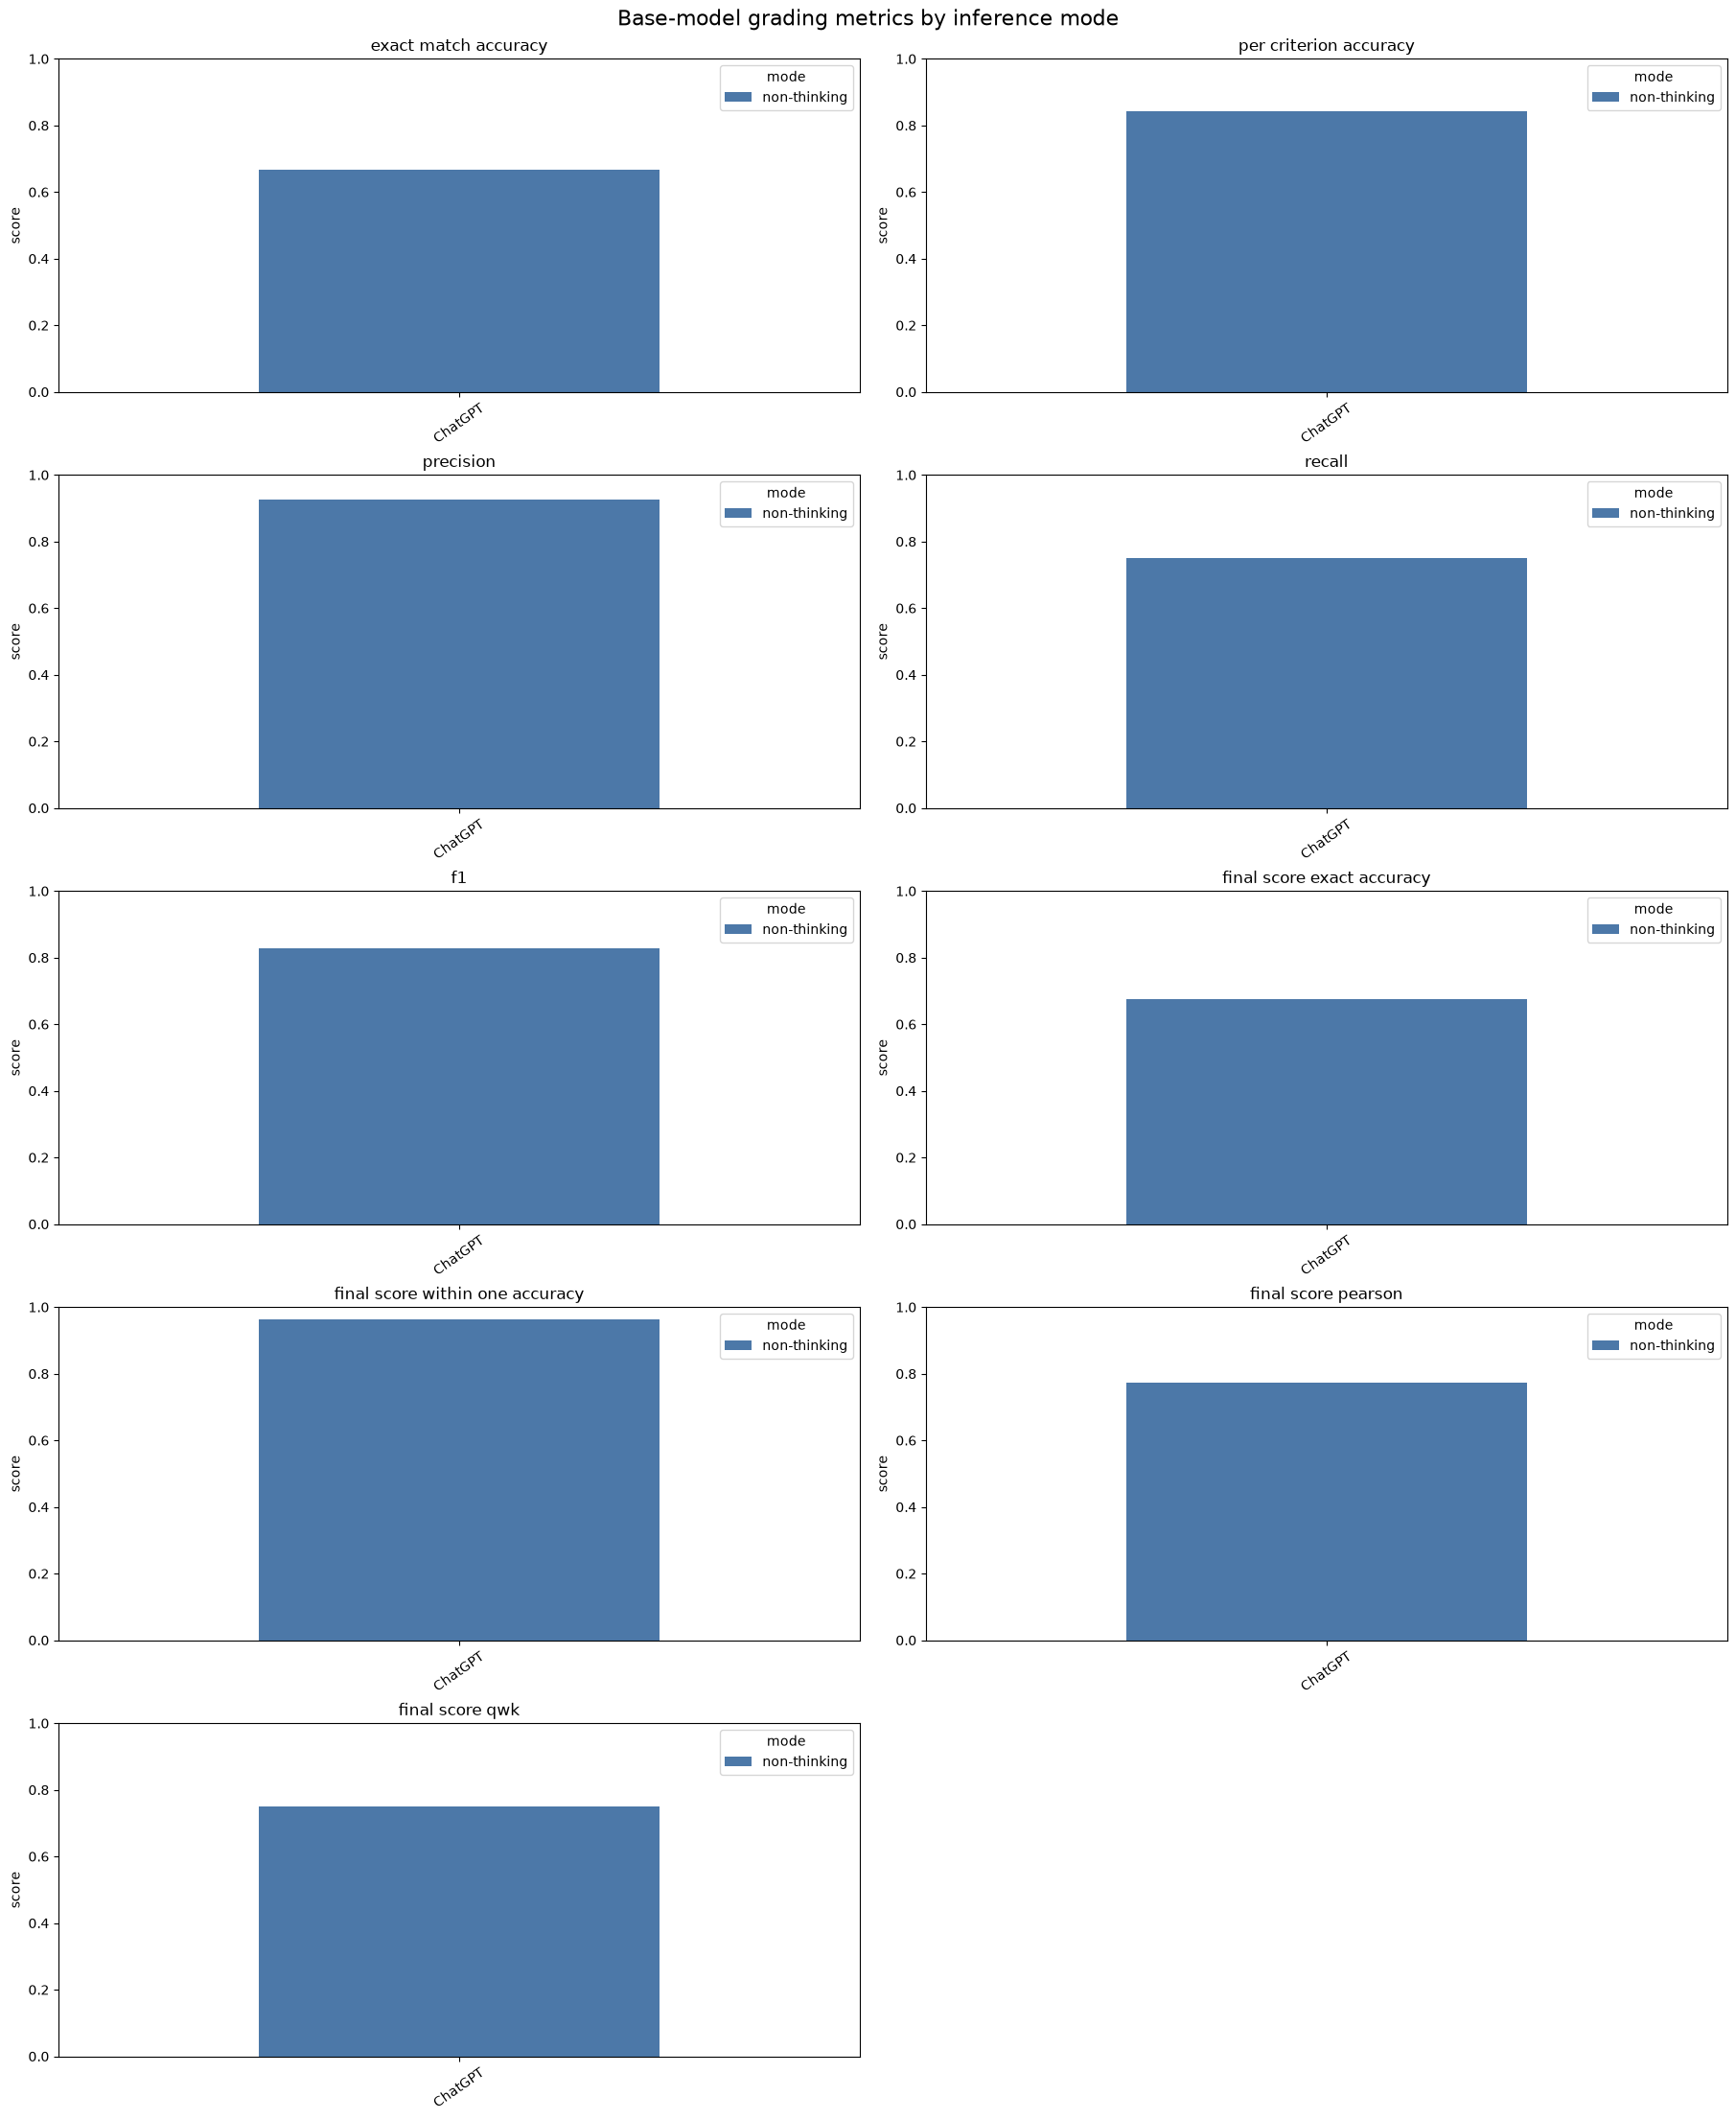

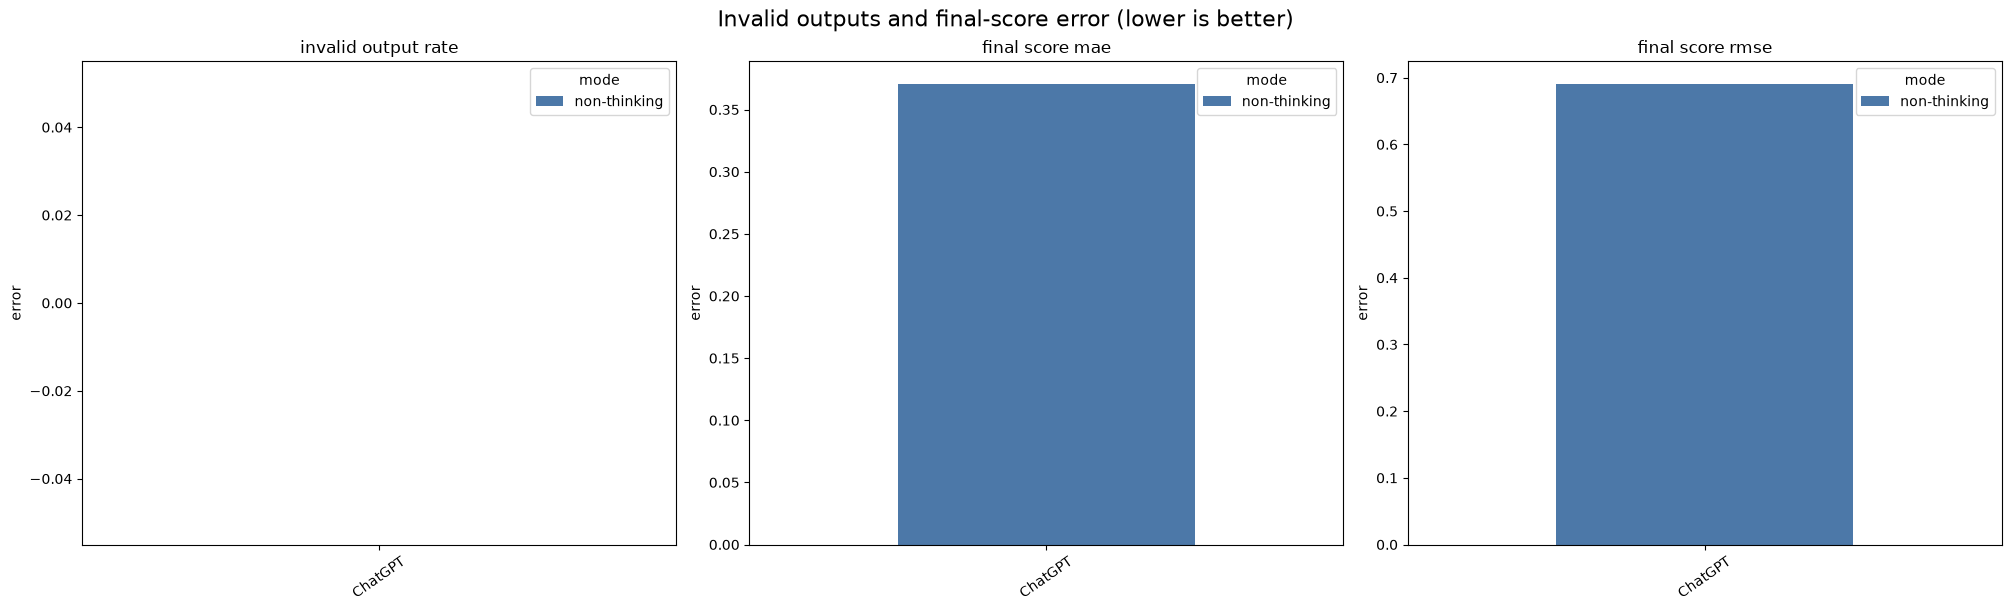

Thinking-delta graph skipped because thinking runs are disabled.


In [22]:
assert_all_runs_complete(summary_df)

accuracy_metrics = [
    "exact_match_accuracy",
    "per_criterion_accuracy",
    "precision",
    "recall",
    "f1",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_pearson",
    "final_score_qwk",
]

# Using 5x2 subplot layout to fit 9 plots gracefully
fig, axes = plt.subplots(5, 2, figsize=(18, 22), constrained_layout=True)
for axis, metric in zip(axes.flat, accuracy_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")

# Hide any unused subplots
for i in range(len(accuracy_metrics), len(axes.flat)):
    axes.flat[i].axis("off")

fig.suptitle("Base-model grading metrics by inference mode", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__accuracy_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

error_metrics = ["invalid_output_rate", "final_score_mae", "final_score_rmse"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for axis, metric in zip(axes, error_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("error")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")
fig.suptitle("Invalid outputs and final-score error (lower is better)", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__error_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

available_modes = set(summary_df["mode"])
if {"non-thinking", "thinking"}.issubset(available_modes):
    delta_metrics = [
        "exact_match_accuracy", "per_criterion_accuracy", "f1",
        "final_score_exact_accuracy", "final_score_pearson", "final_score_qwk"
    ]
    delta_columns = []
    for metric in delta_metrics:
        pivot = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
        delta_columns.append((pivot["thinking"] - pivot["non-thinking"]).rename(metric))
    thinking_delta_df = pd.concat(delta_columns, axis=1)
    axis = thinking_delta_df.plot(kind="bar", figsize=(16, 7))
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title("Thinking-mode change relative to non-thinking")
    axis.set_ylabel("thinking minus non-thinking")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{RUN_TAG}__thinking_delta.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(thinking_delta_df.round(4))
else:
    print("Thinking-delta graph skipped because thinking runs are disabled.")
